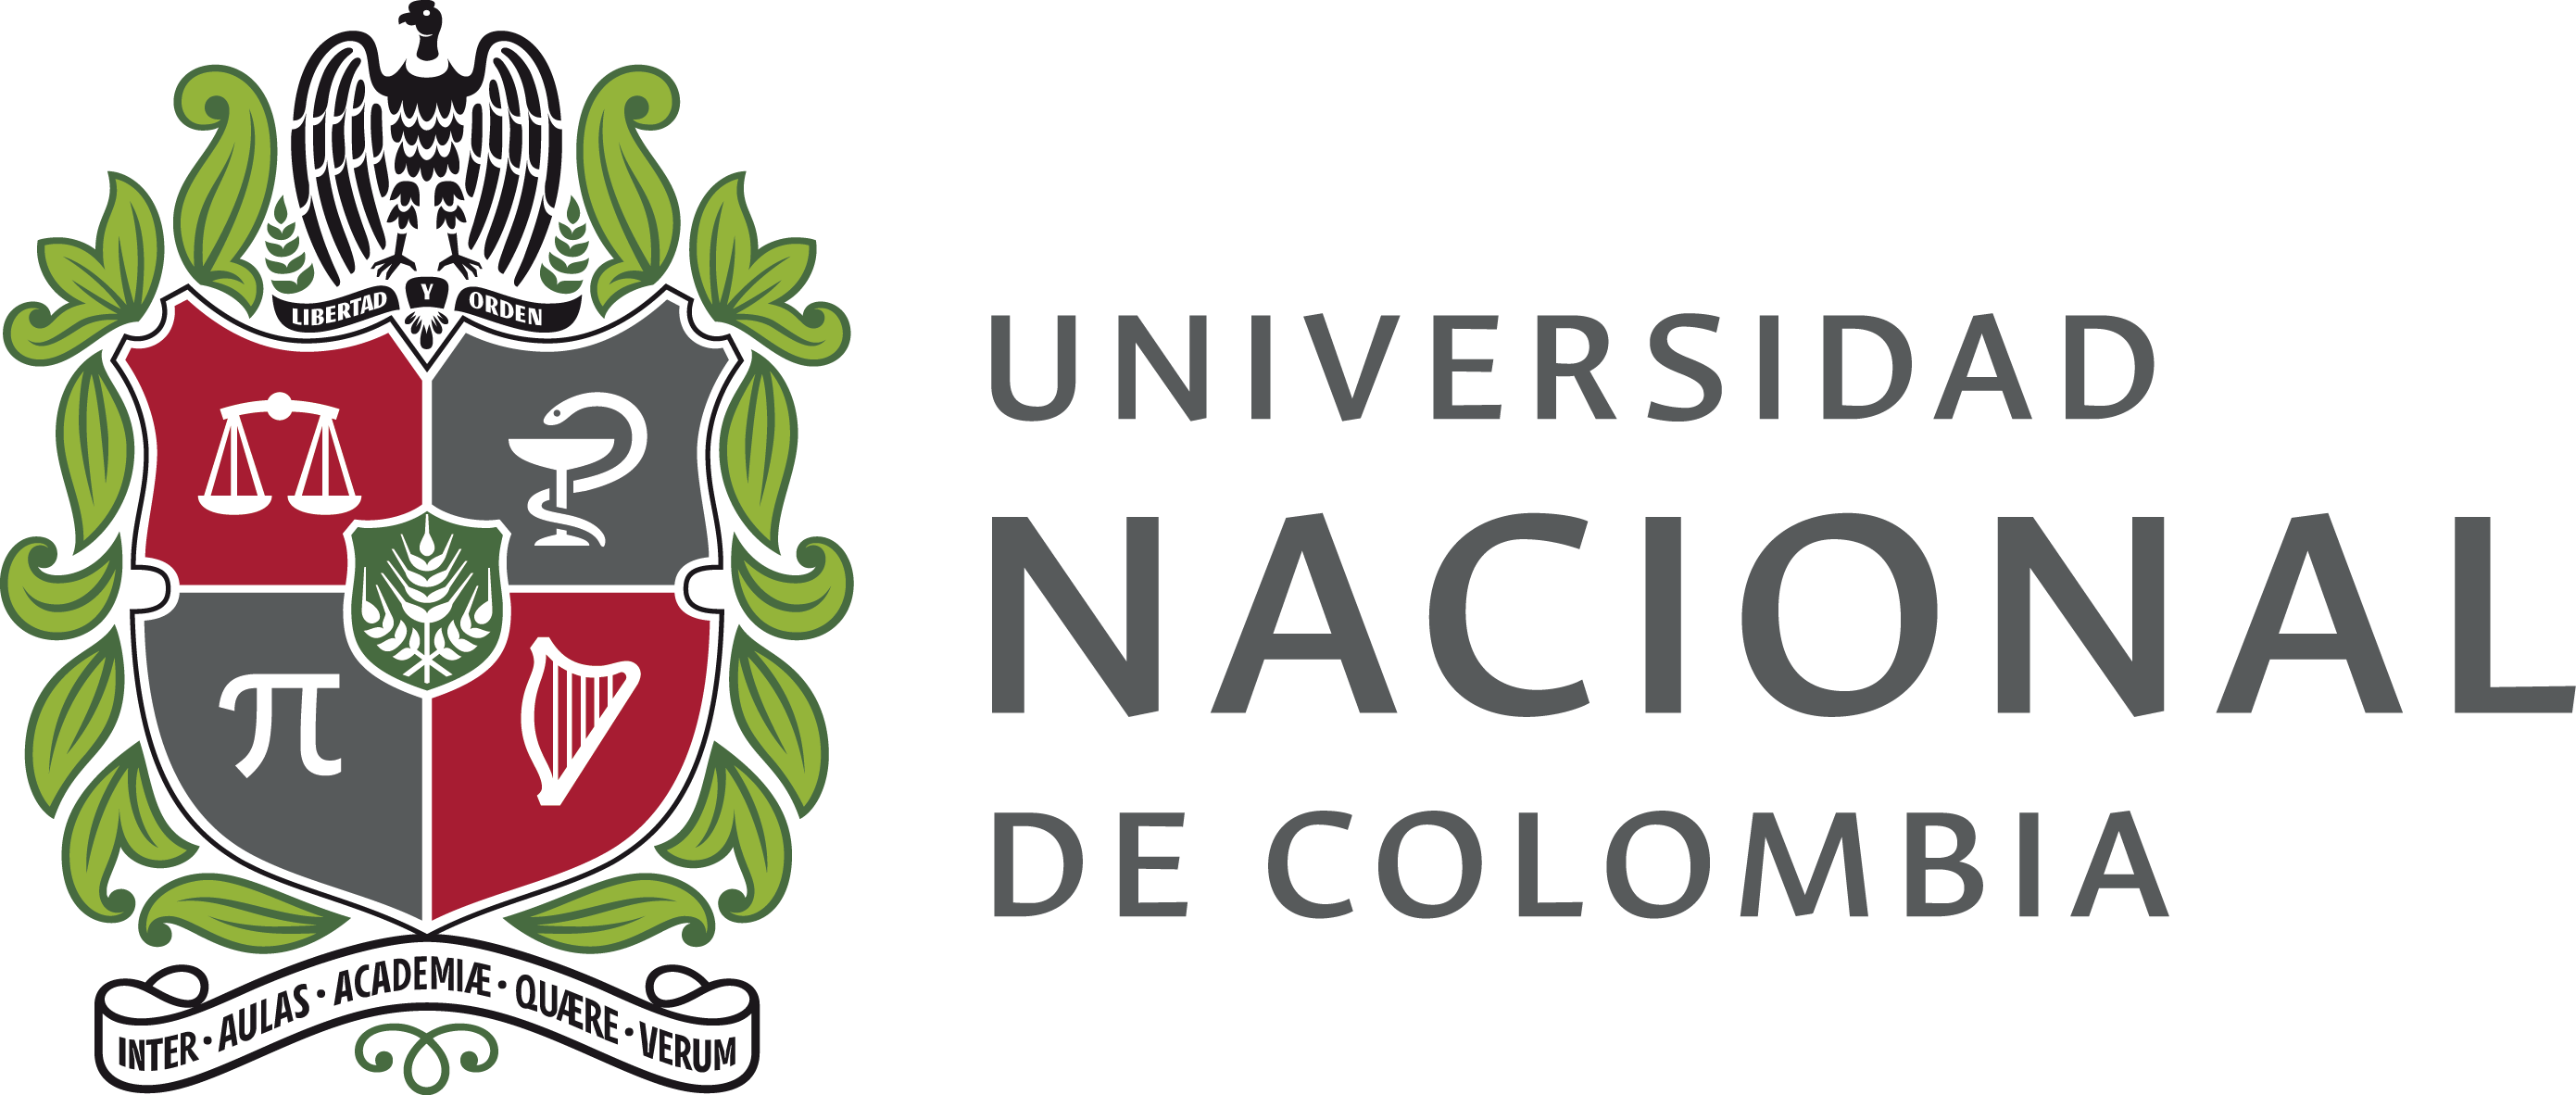
### **Universidad Nacional de Colombia sede Manizales**
#### Facultad de ingeniería y arquitectura
#### Departamento de ingeniería eléctrica, electrónica y computación
#### *Procesamiento digital de imágenes*

#### Profesor: Lucas Iturriago

### Instalar bibliotecas de Python

In [1]:
%%capture
!pip install roboflow

### Importar bibliotecas de Python

In [3]:
import os
import re
import glob
import time
import random
import numpy as np
import seaborn as sns
from tqdm import tqdm
from pathlib import Path
from roboflow import Roboflow
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torchvision.io import decode_image, ImageReadMode

### Descargar base de datos

In [4]:
rf = Roboflow(api_key="9smAmQgaD8pNOTsDMYKR")
project = rf.workspace("roboflow-universe-projects").project("banana-ripeness-classification")
version = project.version(1)
dataset = version.download("folder")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Banana-Ripeness-Classification-1 in folder:: 100%|██████████| 5639/5639 [00:00<00:00, 8480.45it/s]


### Fijar semilla

In [5]:
seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)

### Crear tf.Dataset

In [6]:
class ClassificationDataset(Dataset):
    def __init__(self, data_dir, image_size, partition, augment=True):
        """
        PyTorch Dataset para clasificación de imágenes.

        Args:
            data_dir: Directorio raíz con las particiones (train/val/test)
            image_size: Tupla (height, width) para redimensionar imágenes
            partition: 'train', 'val' o 'test'
            augment: Si aplicar data augmentation (solo en train)
        """
        self.data_dir = Path(data_dir)
        self.image_size = image_size
        self.partition = partition
        self.augment = augment and (partition.lower() == 'train')

        # Cargar estructura de clases
        partition_path = self.data_dir / self.partition
        self.class_folders = sorted([d for d in partition_path.iterdir() if d.is_dir()])
        self.class_to_idx = {cls.name: idx for idx, cls in enumerate(self.class_folders)}
        self.num_classes = len(self.class_folders)

        # Recolectar samples
        self.samples = []
        self.labels = []

        supported_formats = ['*.png', '*.jpg', '*.jpeg', '*.gif', '*.webp']

        for class_folder in tqdm(self.class_folders, desc="Loading dataset"):
            class_idx = self.class_to_idx[class_folder.name]
            for format_pattern in supported_formats:
                files = glob.glob(str(class_folder / format_pattern))
                for file_path in files:
                    self.samples.append(file_path)
                    self.labels.append(class_idx)

        # Ordenar alfabéticamente
        sorted_pairs = sorted(zip(self.samples, self.labels),
                            key=lambda pair: self._alphanumeric_key(pair[0]))
        self.samples, self.labels = zip(*sorted_pairs)
        self.samples = list(self.samples)
        self.labels = list(self.labels)

        self.num_samples = len(self.samples)
        print(f"Found {self.num_samples} images across {self.num_classes} classes in {partition}")

        # Guardar mapeo de clases
        if partition.lower() == 'train':
            with open('class_mapping.txt', 'w') as f:
                f.write("Class Name -> Label Index\n")
                f.write("-" * 30 + "\n")
                for class_name, idx in sorted(self.class_to_idx.items(), key=lambda x: x[1]):
                    f.write(f"{class_name} -> {idx}\n")
            print(f"Class mapping saved to class_mapping.txt")

    @staticmethod
    def _alphanumeric_key(s):
        """Clave para ordenamiento alfanumérico natural"""
        return [int(part) if part.isdigit() else part for part in re.split(r'(\d+)', s)]

    def _load_and_preprocess_image(self, img_path):
        """Carga y preprocesa una imagen usando decode_image"""
        # Decodificar imagen directamente desde el path
        # decode_image retorna tensor en formato [C, H, W] con valores uint8 [0, 255]
        image = decode_image(img_path, mode=ImageReadMode.RGB, apply_exif_orientation=True)
        
        # Convertir a float32 y normalizar a [0, 1]
        image = image.float() / 255.0
        
        # Redimensionar a tamaño deseado
        image = TF.resize(image, self.image_size, antialias=True)
        
        return image

    def _augment_image(self, image):
        """Aplica data augmentation"""
        # Horizontal flip
        if random.random() > 0.5:
            image = TF.hflip(image)

        # Vertical flip
        if random.random() > 0.5:
            image = TF.vflip(image)

        # Brightness
        if random.random() > 0.5:
            brightness_factor = random.uniform(0.8, 1.2)
            image = TF.adjust_brightness(image, brightness_factor)

        # Contrast
        if random.random() > 0.5:
            contrast_factor = random.uniform(0.8, 1.2)
            image = TF.adjust_contrast(image, contrast_factor)

        # Saturation
        if random.random() > 0.5:
            saturation_factor = random.uniform(0.8, 1.2)
            image = TF.adjust_saturation(image, saturation_factor)

        # Gaussian noise
        if random.random() > 0.7:
            noise = torch.randn_like(image) * 0.02
            image = image + noise

        # Clip values
        image = torch.clamp(image, 0.0, 1.0)

        return image

    def __len__(self):
        """Retorna el número de samples"""
        return self.num_samples

    def __getitem__(self, idx):
        """Obtiene un sample del dataset"""
        # Cargar y preprocesar imagen
        img_path = self.samples[idx]
        image = self._load_and_preprocess_image(img_path)
        
        # Aplicar augmentation si corresponde
        if self.augment:
            image = self._augment_image(image)
        
        # Obtener label
        label = self.labels[idx]
        
        return image, label

class ClassificationDataLoader:
    def __init__(self, data_dir, batch_size, image_size, partition, augment=True,
                 num_workers=4, pin_memory=True, shuffle=True):
        """
        PyTorch DataLoader wrapper para clasificación de imágenes.

        Args:
            data_dir: Directorio raíz con las particiones (train/val/test)
            batch_size: Tamaño del batch
            image_size: Tupla (height, width) para redimensionar imágenes
            partition: 'train', 'val' o 'test'
            augment: Si aplicar data augmentation (solo en train)
            num_workers: Número de workers para cargar datos
            pin_memory: Si usar pinned memory (útil para GPU)
            shuffle: Si hacer shuffle
        """
        self.batch_size = batch_size
        self.partition = partition
        
        # Crear dataset
        self.dataset = ClassificationDataset(
            data_dir=data_dir,
            image_size=image_size,
            partition=partition,
            augment=augment
        )
        
        # Determinar si hacer shuffle
        shuffle = shuffle and (partition.lower() == 'train')
        
        # Crear dataloader
        self.dataloader = DataLoader(
            self.dataset,
            batch_size=batch_size,
            shuffle=shuffle,
            num_workers=num_workers,
            pin_memory=pin_memory,
            drop_last=False
        )
        
        self.num_classes = self.dataset.num_classes
        self.class_to_idx = self.dataset.class_to_idx
        self.num_samples = self.dataset.num_samples

    def __len__(self):
        """Retorna el número de batches"""
        return len(self.dataloader)

    def __iter__(self):
        """Permite iterar sobre el dataloader"""
        return iter(self.dataloader)

    def get_dataloader(self):
        """Retorna el DataLoader de PyTorch"""
        return self.dataloader

In [7]:
# Crear dataloader para entrenamiento
train_loader = ClassificationDataLoader(
    data_dir='./Banana-Ripeness-Classification-1',
    batch_size=32,
    image_size=(128, 128),
    partition='train',
    augment=True,
    num_workers=4,
    pin_memory=True,
    shuffle=True
)

# Crear dataloader para validación
val_loader = ClassificationDataLoader(
    data_dir='./Banana-Ripeness-Classification-1',
    batch_size=32,
    image_size=(128, 128),
    partition='valid',
    augment=False,
    num_workers=4,
    pin_memory=True,
    shuffle=False
)

# Crear dataloader para evaluación
test_loader = ClassificationDataLoader(
    data_dir='./Banana-Ripeness-Classification-1',
    batch_size=1,
    image_size=(128, 128),
    partition='test',
    augment=False,
    num_workers=4,
    pin_memory=True,
    shuffle=False
)

Loading dataset: 100%|██████████| 6/6 [00:00<00:00, 188.57it/s]


Found 3931 images across 6 classes in train
Class mapping saved to class_mapping.txt


Loading dataset: 100%|██████████| 6/6 [00:00<00:00, 625.98it/s]


Found 1123 images across 6 classes in valid


Loading dataset: 100%|██████████| 6/6 [00:00<00:00, 1033.63it/s]

Found 562 images across 6 classes in test


### Crear y definir modelo

In [8]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, name=None):
        """
        Bloque residual básico.
        
        Args:
            in_channels: Número de canales de entrada
            out_channels: Número de canales de salida (filters)
            stride: Stride para la primera convolución
            name: Nombre del bloque (opcional, para debugging)
        """
        super(ResidualBlock, self).__init__()
        self.name = name
        
        # Rama principal
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, 
                               stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu1 = nn.ReLU(inplace=True)
        
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                               stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        
        # Proyección del shortcut si cambia dimensión
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1,
                         stride=stride, padding=0, bias=False),
                nn.BatchNorm2d(out_channels)
            )
        
        self.relu_out = nn.ReLU(inplace=True)
    
    def forward(self, x):
        # Guardar shortcut
        shortcut = self.shortcut(x)
        
        # Rama principal
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu1(out)
        
        out = self.conv2(out)
        out = self.bn2(out)
        
        # Suma residual
        out = out + shortcut
        out = self.relu_out(out)
        
        return out


class ResNetCustom(nn.Module):
    def __init__(self, num_classes, input_shape=(3, 224, 224), dropout_rate=0.3):
        """
        Modelo ResNet personalizado para clasificación.
        
        Args:
            num_classes: Número de clases para clasificación
            input_shape: Forma de entrada (channels, height, width)
            dropout_rate: Tasa de dropout antes de la capa final
        """
        super(ResNetCustom, self).__init__()
        
        self.num_classes = num_classes
        self.input_shape = input_shape
        self.dropout_rate = dropout_rate
        
        # Stem
        self.stem_conv = nn.Conv2d(input_shape[0], 64, kernel_size=7,
                                   stride=2, padding=3, bias=False)
        self.stem_bn = nn.BatchNorm2d(64)
        self.stem_relu = nn.ReLU(inplace=True)
        self.stem_pool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        
        # Bloques residuales
        self.block1_1 = ResidualBlock(64, 64, stride=1, name="block1_1")
        self.block1_2 = ResidualBlock(64, 64, stride=1, name="block1_2")
        
        self.block2_1 = ResidualBlock(64, 128, stride=2, name="block2_1")
        self.block2_2 = ResidualBlock(128, 128, stride=1, name="block2_2")
        
        self.block3_1 = ResidualBlock(128, 256, stride=2, name="block3_1")
        self.block3_2 = ResidualBlock(256, 256, stride=1, name="block3_2")
        
        self.block4_1 = ResidualBlock(256, 512, stride=2, name="block4_1")
        self.block4_2 = ResidualBlock(512, 512, stride=1, name="block4_2")
        
        # Clasificador
        self.global_avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(p=dropout_rate)
        self.fc = nn.Linear(512, num_classes)
        
    def forward(self, x):
        # Stem
        x = self.stem_conv(x)
        x = self.stem_bn(x)
        x = self.stem_relu(x)
        x = self.stem_pool(x)
        
        # Bloques residuales
        x = self.block1_1(x)
        x = self.block1_2(x)
        
        x = self.block2_1(x)
        x = self.block2_2(x)
        
        x = self.block3_1(x)
        x = self.block3_2(x)
        
        x = self.block4_1(x)
        x = self.block4_2(x)
        
        # Clasificador
        x = self.global_avg_pool(x)
        x = torch.flatten(x, 1)  # Flatten manteniendo batch dimension
        x = self.dropout(x)
        x = self.fc(x)
        
        return x
    
    def predict(self, x):
        """Retorna probabilidades con softmax (equivalente al modelo de Keras)"""
        logits = self.forward(x)
        return F.softmax(logits, dim=1)


def create_classification_model(num_classes, input_shape=(3, 224, 224), 
                               dropout_rate=0.3, learning_rate=1e-3):
    """
    Función helper para crear el modelo (similar a la versión de Keras).
    
    Args:
        num_classes: Número de clases
        input_shape: Tupla (channels, height, width) - Nota: PyTorch usa CHW
        dropout_rate: Tasa de dropout
        learning_rate: Learning rate (para referencia, no se usa aquí)
    
    Returns:
        model: Modelo ResNetCustom
    """
    model = ResNetCustom(
        num_classes=num_classes,
        input_shape=input_shape,
        dropout_rate=dropout_rate
    )
    
    return model

In [9]:
model = create_classification_model(
        num_classes=6,
        input_shape=(3,128,128),
        dropout_rate=0.1)

In [10]:
print(model)

ResNetCustom(
  (stem_conv): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (stem_bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (stem_relu): ReLU(inplace=True)
  (stem_pool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (block1_1): ResidualBlock(
    (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu1): ReLU(inplace=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (shortcut): Sequential()
    (relu_out): ReLU(inplace=True)
  )
  (block1_2): ResidualBlock(
    (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True,

### Entrenamiento del modelo

In [ ]:
class TrainingHistory:
    """Clase para almacenar el historial de entrenamiento (similar a Keras)"""
    def __init__(self):
        self.history = {
            'loss': [],
            'accuracy': [],
            'top5_accuracy': [],
            'val_loss': [],
            'val_accuracy': [],
            'val_top5_accuracy': []
        }
    
    def update(self, metrics_dict):
        """Actualiza el historial con las métricas de una época"""
        for key, value in metrics_dict.items():
            if key in self.history:
                self.history[key].append(value)


class EarlyStopping:
    """Early stopping para detener el entrenamiento cuando no hay mejora"""
    def __init__(self, patience=10, min_delta=0, mode='min', verbose=True):
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.best_model_state = None
        
    def __call__(self, score, model):
        if self.best_score is None:
            self.best_score = score
            self.best_model_state = model.state_dict().copy()
        elif self._is_improvement(score):
            self.best_score = score
            self.best_model_state = model.state_dict().copy()
            self.counter = 0
        else:
            self.counter += 1
            if self.verbose:
                print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
                if self.verbose:
                    print('Early stopping triggered')
    
    def _is_improvement(self, score):
        if self.mode == 'min':
            return score < (self.best_score - self.min_delta)
        else:
            return score > (self.best_score + self.min_delta)
    
    def restore_best_weights(self, model):
        """Restaura los mejores pesos del modelo"""
        if self.best_model_state is not None:
            model.load_state_dict(self.best_model_state)
            if self.verbose:
                print('Restored best model weights')


def calculate_accuracy(outputs, labels):
    """Calcula accuracy top-1"""
    _, predicted = torch.max(outputs, 1)
    correct = (predicted == labels).sum().item()
    total = labels.size(0)
    return correct / total


def calculate_top5_accuracy(outputs, labels):
    """Calcula accuracy top-5"""
    _, predicted = torch.topk(outputs, k=min(5, outputs.size(1)), dim=1)
    correct = 0
    for i in range(labels.size(0)):
        if labels[i] in predicted[i]:
            correct += 1
    return correct / labels.size(0)


def train_epoch(model, dataloader, criterion, optimizer, device):
    """Entrena una época"""
    model.train()
    running_loss = 0.0
    running_acc = 0.0
    running_top5_acc = 0.0
    num_batches = 0
    
    pbar = tqdm(dataloader, desc='Training')
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Calcular métricas
        running_loss += loss.item()
        running_acc += calculate_accuracy(outputs, labels)
        running_top5_acc += calculate_top5_accuracy(outputs, labels)
        num_batches += 1
        
        # Actualizar progress bar
        pbar.set_postfix({
            'loss': running_loss / num_batches,
            'acc': running_acc / num_batches
        })
    
    epoch_loss = running_loss / num_batches
    epoch_acc = running_acc / num_batches
    epoch_top5_acc = running_top5_acc / num_batches
    
    return epoch_loss, epoch_acc, epoch_top5_acc


def validate_epoch(model, dataloader, criterion, device):
    """Valida una época"""
    model.eval()
    running_loss = 0.0
    running_acc = 0.0
    running_top5_acc = 0.0
    num_batches = 0
    
    with torch.no_grad():
        pbar = tqdm(dataloader, desc='Validation')
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)
            
            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            # Calcular métricas
            running_loss += loss.item()
            running_acc += calculate_accuracy(outputs, labels)
            running_top5_acc += calculate_top5_accuracy(outputs, labels)
            num_batches += 1
            
            # Actualizar progress bar
            pbar.set_postfix({
                'loss': running_loss / num_batches,
                'acc': running_acc / num_batches
            })
    
    epoch_loss = running_loss / num_batches
    epoch_acc = running_acc / num_batches
    epoch_top5_acc = running_top5_acc / num_batches
    
    return epoch_loss, epoch_acc, epoch_top5_acc


def train_model(model, train_loader, val_loader, epochs=50, learning_rate=1e-3,
                device='cuda', save_path='best_model.pth'):
    """
    Entrena el modelo (equivalente a model.fit de Keras)
    
    Args:
        model: Modelo PyTorch
        train_loader: DataLoader de entrenamiento
        val_loader: DataLoader de validación
        epochs: Número de épocas
        learning_rate: Learning rate inicial
        device: 'cuda' o 'cpu'
        save_path: Ruta para guardar el mejor modelo
    
    Returns:
        history: Objeto TrainingHistory con las métricas
    """
    # Mover modelo a device
    model = model.to(device)
    
    # Definir loss y optimizer (equivalente a model.compile)
    criterion = nn.CrossEntropyLoss()  # Equivalente a SparseCategoricalCrossentropy
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    # Scheduler (equivalente a ReduceLROnPlateau)
    scheduler = ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
    )
    
    # Early stopping
    early_stopping = EarlyStopping(
        patience=10,
        mode='min',
        verbose=True
    )
    
    # Historial
    history = TrainingHistory()
    
    # Mejor accuracy para guardar modelo
    best_val_acc = 0.0
    
    print(f"\nStarting training on {device}")
    print(f"Total epochs: {epochs}")
    print(f"Train batches: {len(train_loader)}")
    print(f"Val batches: {len(val_loader)}")
    print("-" * 80)
    
    # Loop de entrenamiento
    for epoch in range(epochs):
        print(f"\nEpoch {epoch + 1}/{epochs}")
        
        # Entrenar
        train_loss, train_acc, train_top5_acc = train_epoch(
            model, train_loader, criterion, optimizer, device
        )
        
        # Validar
        val_loss, val_acc, val_top5_acc = validate_epoch(
            model, val_loader, criterion, device
        )
        
        # Actualizar historial
        history.update({
            'loss': train_loss,
            'accuracy': train_acc,
            'top5_accuracy': train_top5_acc,
            'val_loss': val_loss,
            'val_accuracy': val_acc,
            'val_top5_accuracy': val_top5_acc
        })
        
        # Imprimir métricas
        print(f"\nResults:")
        print(f"  Train - Loss: {train_loss:.4f}, Acc: {train_acc:.4f}, Top5: {train_top5_acc:.4f}")
        print(f"  Val   - Loss: {val_loss:.4f}, Acc: {val_acc:.4f}, Top5: {val_top5_acc:.4f}")
        print(f"  LR: {optimizer.param_groups[0]['lr']:.2e}")
        
        # Guardar mejor modelo (ModelCheckpoint)
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_accuracy': val_acc,
                'val_loss': val_loss,
            }, save_path)
            print(f"  Saved best model (val_acc: {val_acc:.4f})")
        
        # Actualizar learning rate
        scheduler.step(val_loss)
        
        # Early stopping
        early_stopping(val_loss, model)
        if early_stopping.early_stop:
            print(f"\nEarly stopping at epoch {epoch + 1}")
            early_stopping.restore_best_weights(model)
            break
    
    print("\n" + "=" * 80)
    print("Training completed!")
    print(f"Best validation accuracy: {best_val_acc:.4f}")
    
    return history

In [12]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

history = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        epochs=50,
        learning_rate=1e-3,
        device=device,
        save_path='best_model.pth'
    )

Using device: cuda

Starting training on cuda
Total epochs: 50
Train batches: 123
Val batches: 36
--------------------------------------------------------------------------------

Epoch 1/50


Validation: 100%|██████████| 36/36 [00:02<00:00, 14.37it/s, loss=1.85, acc=0.517]



Results:
  Train - Loss: 0.8777, Acc: 0.6762, Top5: 0.9903
  Val   - Loss: 1.8452, Acc: 0.5174, Top5: 0.9690
  LR: 1.00e-03
  ✓ Saved best model (val_acc: 0.5174)

Epoch 2/50


Validation: 100%|██████████| 36/36 [00:02<00:00, 14.47it/s, loss=2.92, acc=0.374] 



Results:
  Train - Loss: 0.5621, Acc: 0.7979, Top5: 0.9995
  Val   - Loss: 2.9157, Acc: 0.3741, Top5: 0.9661
  LR: 1.00e-03
EarlyStopping counter: 1 out of 10

Epoch 3/50


...


Results:
  Train - Loss: 0.0218, Acc: 0.9921, Top5: 1.0000
  Val   - Loss: 0.0950, Acc: 0.9705, Top5: 1.0000
  LR: 3.13e-05
EarlyStopping counter: 8 out of 10

Epoch 46/50


Validation: 100%|██████████| 36/36 [00:02<00:00, 15.61it/s, loss=0.0984, acc=0.97] 



Results:
  Train - Loss: 0.0192, Acc: 0.9939, Top5: 1.0000
  Val   - Loss: 0.0984, Acc: 0.9705, Top5: 1.0000
  LR: 1.56e-05
EarlyStopping counter: 9 out of 10

Epoch 47/50


Validation: 100%|██████████| 36/36 [00:02<00:00, 15.89it/s, loss=0.0958, acc=0.973]


Results:
  Train - Loss: 0.0233, Acc: 0.9931, Top5: 1.0000
  Val   - Loss: 0.0958, Acc: 0.9731, Top5: 1.0000
  LR: 1.56e-05
EarlyStopping counter: 10 out of 10
Early stopping triggered

Early stopping at epoch 47
Restored best model weights

Training completed!
Best validation accuracy: 0.9740


### Evolución del entrenamiento

In [13]:
def plot_detailed_history(history, save_path='detailed_history.png'):
    """
    Grafica el historial con más detalle (incluye top-5 accuracy si está disponible)

    Args:
        history: Objeto TrainingHistory con las métricas
        save_path: Ruta donde guardar la imagen
    """
    # Verificar qué métricas están disponibles
    available_metrics = list(history.history.keys())
    has_top5 = 'top5_accuracy' in available_metrics and len(history.history['top5_accuracy']) > 0

    # Determinar número de subplots
    n_plots = 3 if has_top5 else 2
    fig, axes = plt.subplots(1, n_plots, figsize=(7*n_plots, 5))

    if n_plots == 2:
        ax1, ax2 = axes
    else:
        ax1, ax2, ax3 = axes

    epochs = range(1, len(history.history['loss']) + 1)

    # Plot 1: Loss
    ax1.plot(epochs, history.history['loss'], 'b-o', label='Train', linewidth=2, markersize=4)
    ax1.plot(epochs, history.history['val_loss'], 'r-s', label='Val', linewidth=2, markersize=4)
    ax1.set_title('Loss', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Loss', fontsize=12)
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)

    # Plot 2: Accuracy
    ax2.plot(epochs, history.history['accuracy'], 'b-o', label='Train', linewidth=2, markersize=4)
    ax2.plot(epochs, history.history['val_accuracy'], 'r-s', label='Val', linewidth=2, markersize=4)
    ax2.set_title('Accuracy', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Accuracy', fontsize=12)
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)

    # Plot 3: Top-5 Accuracy (si está disponible)
    if has_top5:
        ax3.plot(epochs, history.history['top5_accuracy'], 'b-o', label='Train', linewidth=2, markersize=4)
        ax3.plot(epochs, history.history['val_top5_accuracy'], 'r-s', label='Val', linewidth=2, markersize=4)
        ax3.set_title('Top-5 Accuracy', fontsize=14, fontweight='bold')
        ax3.set_xlabel('Epoch', fontsize=12)
        ax3.set_ylabel('Top-5 Accuracy', fontsize=12)
        ax3.legend(fontsize=10)
        ax3.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Detailed history plot saved to {save_path}")
    plt.show()

Detailed history plot saved to detailed_history.png


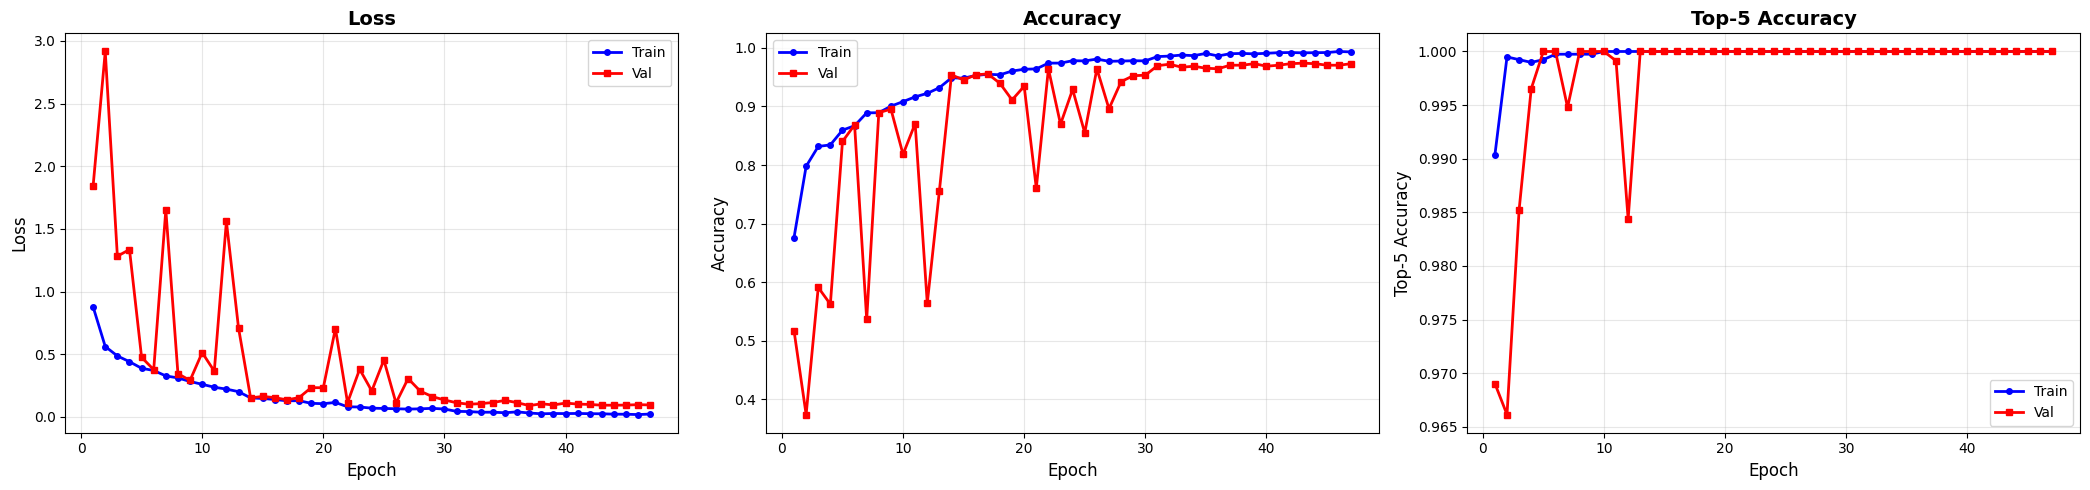

In [14]:
# Graficar historial detallado (incluye top-5 si está disponible)
plot_detailed_history(history)

### Convertir modelo a TorchScript
(en este caso cuantización dinámica, pero puede ser otra)

In [16]:
# Cargar el modelo entrenado
checkpoint = torch.load("best_model.pth")
model = create_classification_model(
    num_classes=6,
    input_shape=(3, 128, 128),
    dropout_rate=0.3
)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

# Convertir a TorchScript
dummy_input = torch.rand(1, 3, 128, 128)

# Cuantización dinámica
quantized_model = torch.quantization.quantize_dynamic(
    model, {torch.nn.Linear}, dtype=torch.qint8
)
traced_quantized = torch.jit.trace(quantized_model, dummy_input)
traced_quantized.save("model_dynamic_quant.pt")

### Comparación de modelos

In [18]:
# Cargar modelos
checkpoint = torch.load("best_model.pth")
model_torch = create_classification_model(
    num_classes=6,
    input_shape=(3, 128, 128),
    dropout_rate=0.3
)
model_torch.load_state_dict(checkpoint['model_state_dict'])
model_torch.eval()

# Cargar modelo TorchScript cuantizado
model_quantized = torch.jit.load("model_dynamic_quant.pt")
model_quantized.eval()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_torch = model_torch.to(device)
model_quantized = model_quantized.to('cpu')  # Cuantizado solo en CPU

In [19]:
# Evaluar accuracy PyTorch y TorchScript cuantizado
correct_torch = 0
correct_quantized = 0
total = 0

# ----- PyTorch normal -----
start_torch = time.time()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model_torch(images)
        preds = torch.argmax(outputs, dim=1)
        correct_torch += (preds == labels).sum().item()
        total += labels.size(0)
end_torch = time.time()

accuracy_torch = correct_torch / total

# ----- TorchScript cuantizado -----
start_quantized = time.time()
with torch.no_grad():
    for images, labels in test_loader:
        images_cpu = images.to('cpu')
        outputs = model_quantized(images_cpu)
        preds = torch.argmax(outputs, dim=1)
        correct_quantized += (preds == labels).sum().item()
end_quantized = time.time()

accuracy_quantized = correct_quantized / total

In [20]:
# Tiempos de inferencia
torch_inference_time = (end_torch - start_torch) / total
quantized_inference_time = (end_quantized - start_quantized) / total

In [21]:
# Tamaño de los modelos
size_torch = os.path.getsize("best_model.pth") / (1024 * 1024)
size_quantized = os.path.getsize("model_dynamic_quant.pt") / (1024 * 1024)

In [22]:
# Resultados
print("======= RESULTADOS =======")
print(f"Accuracy PyTorch:         {accuracy_torch:.4f}")
print(f"Accuracy Quantized:       {accuracy_quantized:.4f}")
print()
print(f"Tiempo por inferencia PyTorch:    {torch_inference_time*1000:.3f} ms")
print(f"Tiempo por inferencia Quantized:  {quantized_inference_time*1000:.3f} ms")
print()
print(f"Peso modelo PyTorch:      {size_torch:.2f} MB")
print(f"Peso modelo Quantized:    {size_quantized:.2f} MB")
print("==========================")

======= RESULTADOS =======
Accuracy PyTorch:         0.9698
Accuracy Quantized:       0.9698

Tiempo por inferencia PyTorch:    5.561 ms
Tiempo por inferencia Quantized:  23.024 ms

Peso modelo PyTorch:      128.07 MB
Peso modelo Quantized:    42.85 MB
